# **Credit Card Fraud Detection System**

## **1. Data Loading**

### **1.1 Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

### **1.2 Load Dataset**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **2. Data Inspection and Understanding**

### **2.1 Dataset exploration**

In [ ]:
df.shape

(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


The dataset is severely imbalanced, models might overfit if not sampled with equal distribution.

### **2.2 Dataset visualization**

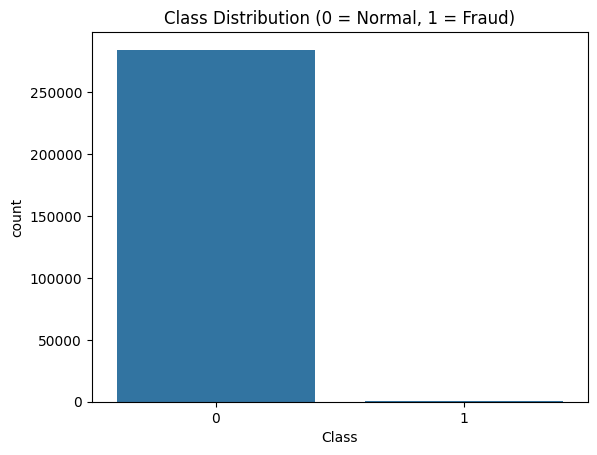

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

/tmp/ipykernel_9265/2718206775.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Time"], color='b')


<Axes: xlabel='Time', ylabel='Density'>

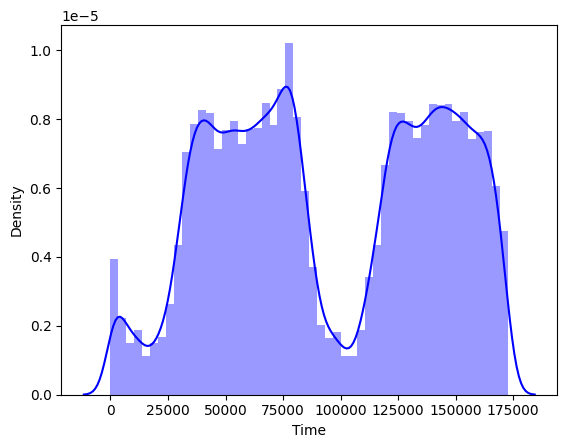

In [ ]:
sns.distplot(df["Time"], color='b')

This covers time in seconds since first transaction, maximum is two days.

Text(0.5, 1.0, 'Transaction Amount Distribution-normal')

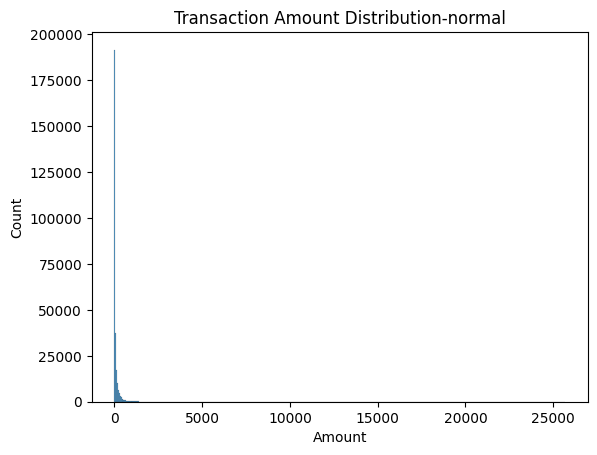

In [ ]:
sns.histplot(df[df['Class'] == 0]['Amount'], bins=500, label='Normal', kde=False)


plt.title("Transaction Amount Distribution-normal")


Text(0.5, 1.0, 'Transaction Amount Distribution-fraud')

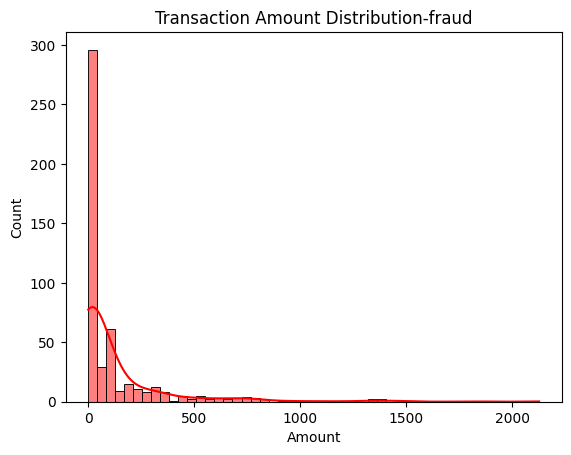

In [ ]:
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', kde=True)
plt.title("Transaction Amount Distribution-fraud")


Fraud transcation amount ranges from 0 to 2300 with most frauds at low amounts.

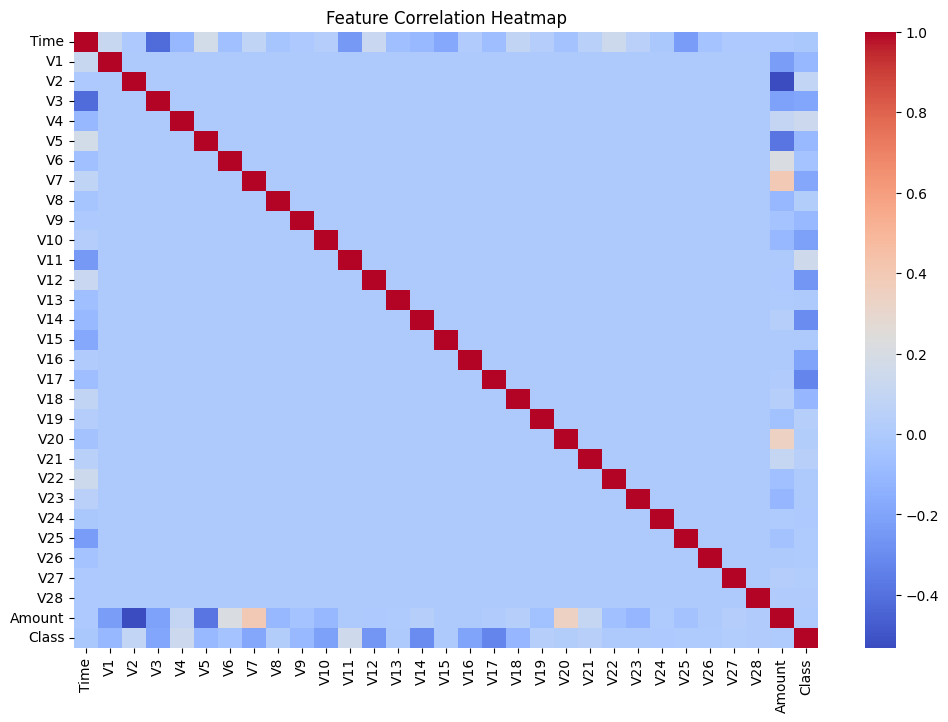

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Most features are PCA-transformed, so direct interpretability is limited.


## **3. Data Processing**


In [ ]:
df = df.drop(columns=['Time'])

The Time feature represents a sequential index rather than meaningful temporal behavior, and without user-level grouping it does not provide useful signal for fraud detection.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


The Amount feature is scaled to ensure that it does not dominate other features during model training.

### 3.2 Split Features


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

##**4.  Model Fitting**

### **4.1 Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

##**5. Model Evaluation**

### **5.1 Logistic Regression**

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9714465520310545


- **Recall (0.92):** The model successfully detects most fraudulent transactions, meaning very few fraud cases are missed.

- **Precision (0.06):** A large number of legitimate transactions are incorrectly classified as fraud, leading to many false positives.

- **Trade-off:** There is a clear trade-off between recall and precision; improving fraud detection increases false alarms.

- **Imbalanced Data Impact:** Due to class imbalance, the model prioritizes identifying fraud (minority class), which reduces precision.

- **ROC-AUC (~0.97):** Indicates strong overall ability to distinguish between fraudulent and non-fraudulent transactions.

- **Practical Implication:** Suitable for scenarios where missing fraud is costly, but requires further tuning to reduce false positives.

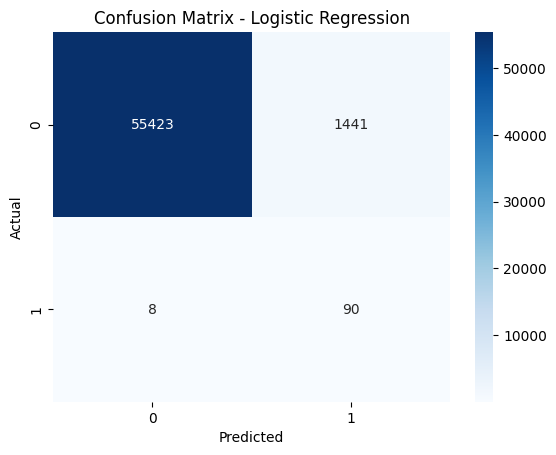

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the model correctly identifies 90 fraudulent transactions while missing only 8, which is desirable in fraud detection. However, it incorrectly flags 1441 normal transactions as fraud, indicating a high number of false positives.                                             This suggests that while the model is effective at catching fraud, it may create operational inefficiencies due to excessive false alerts.

##**5. Threshold Optimization**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append((t, precision, recall, f1))

# Print results
for r in results:
    print(f"Threshold: {r[0]} | Precision: {r[1]:.4f} | Recall: {r[2]:.4f} | F1: {r[3]:.4f}")

Threshold: 0.5 | Precision: 0.0588 | Recall: 0.9184 | F1: 0.1105
Threshold: 0.4 | Precision: 0.0411 | Recall: 0.9184 | F1: 0.0786
Threshold: 0.3 | Precision: 0.0267 | Recall: 0.9184 | F1: 0.0520
Threshold: 0.2 | Precision: 0.0164 | Recall: 0.9388 | F1: 0.0322
Threshold: 0.1 | Precision: 0.0081 | Recall: 0.9490 | F1: 0.0161


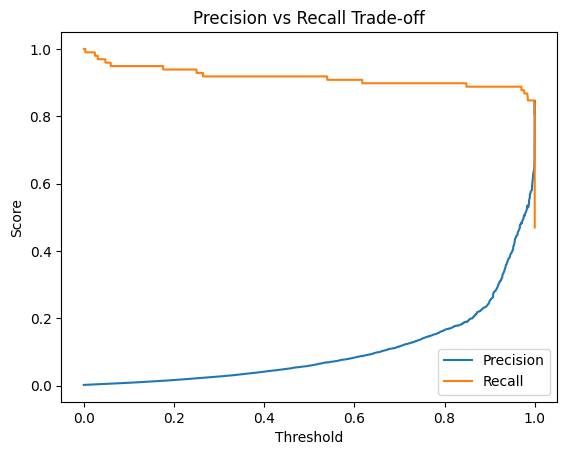

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precision[:-1])
plt.plot(thresholds, recall[:-1])

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Trade-off")
plt.legend(["Precision", "Recall"])
plt.show()

* Recall stays high across most threshold values, meaning the model is already
catching most fraudulent cases
* Precision only improves when the threshold is increased, showing fewer false positives at stricter settings
* Lowering the threshold does not add much value, as recall barely improves
* However, a lower threshold sharply increases false positives, reducing precision
* This suggests the model is already biased toward high recall
* Further gains won't come from tuning the threshold alone
* Improving the model itself (features, algorithm, or data) is necessary for better performance

***Since threshold tuning did not significantly improve performance, a more powerful model is required to better capture complex fraud patterns. Therefore, Random Forest is explored as a non-linear alternative.***

##**6. Random Forest fitting and evaluation**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9580130501131234
PR-AUC: 0.8484819006905729


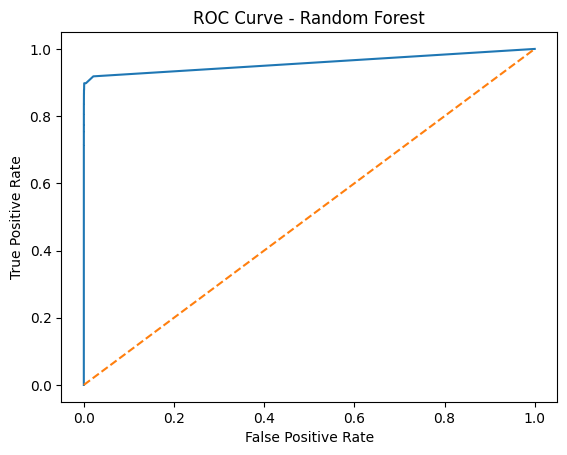

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

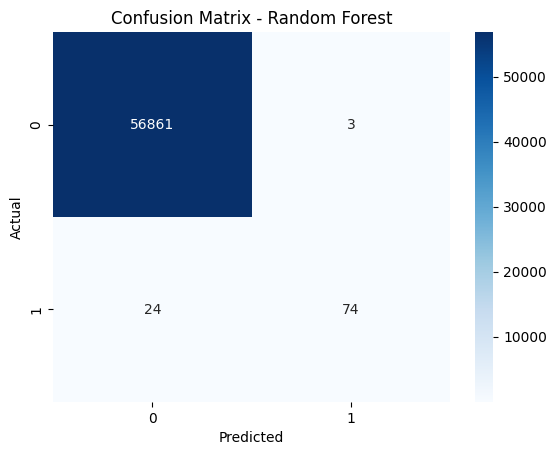

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

* Random Forest significantly improves precision (~0.96), greatly reducing false positives compared to Logistic Regression
* Recall decreases to ~0.76, meaning more fraudulent transactions are missed
* PR-AUC (~0.84) indicates strong performance under class imbalance
* The model becomes more conservative in its predictions
* Prioritizes reducing false alarms over catching every fraud case
* Shows a clear trade-off between precision and recall
* Better suited for scenarios where false positives are costly

#**7. XGBoost**

In [ ]:
from xgboost import XGBClassifier

# handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def get_metrics(y_test, y_pred, y_prob):
    return {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

print(get_metrics(y_test, y_pred_xgb, y_prob_xgb))

{'Precision': 0.7155172413793104, 'Recall': 0.8469387755102041, 'F1': 0.7757009345794392, 'ROC-AUC': np.float64(0.9747345618044629), 'PR-AUC': np.float64(0.8509530510546813)}


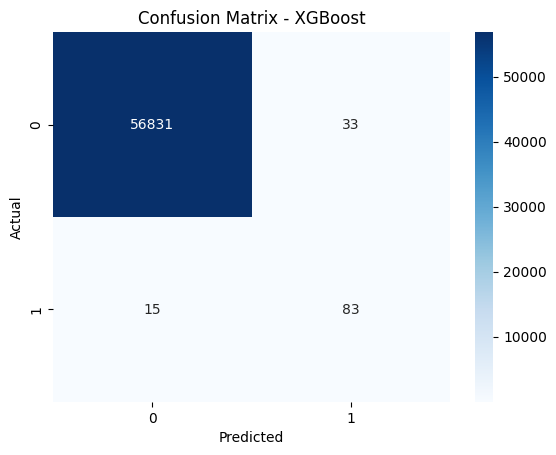

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8. **Model Comparison**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def get_metrics(y_test, y_pred, y_prob):
    return {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

lr_metrics = get_metrics(y_test, y_pred, y_prob)
rf_metrics = get_metrics(y_test, y_pred_rf, y_prob_rf)
xgb_metrics = get_metrics(y_test, y_pred_xgb, y_prob_xgb)


comparison = pd.DataFrame([lr_metrics, rf_metrics,xgb_metrics], index=["Logistic Regression", "Random Forest","XGBoost"])
comparison

,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.058785,0.918367,0.110497,0.971447,0.715586
Random Forest,0.961039,0.755102,0.845714,0.958013,0.848482
XGBoost,0.715517,0.846939,0.775701,0.974735,0.850953


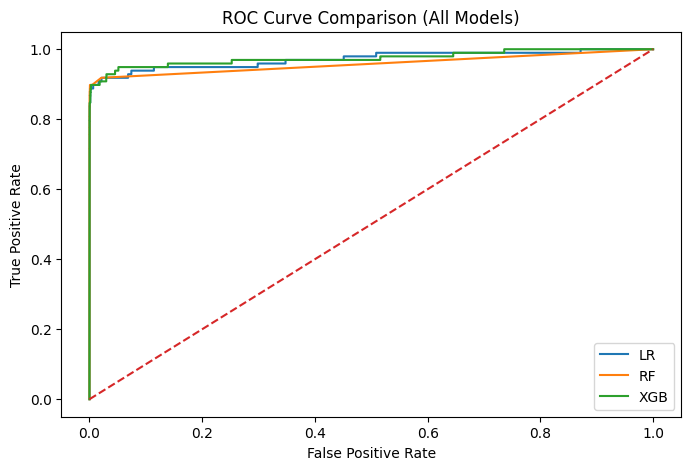

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve

# LR
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

# RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)


# XGB
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,5))

plt.plot(fpr_lr, tpr_lr, label="LR")
plt.plot(fpr_rf, tpr_rf, label="RF")
plt.plot(fpr_xgb, tpr_xgb, label="XGB")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.show()
plt.figure(figsize=(8,5))


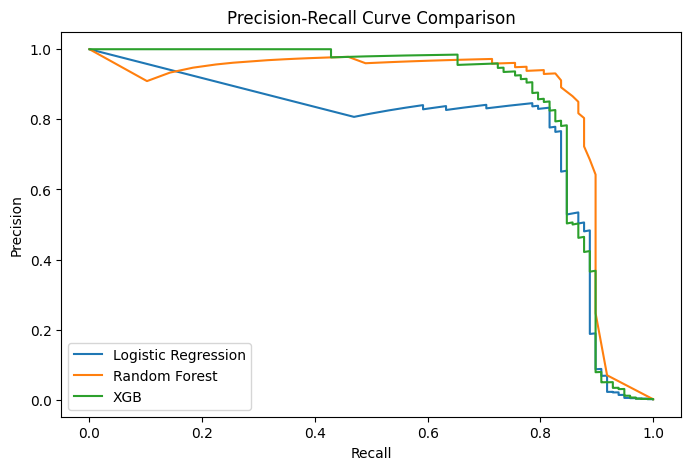

In [ ]:
from sklearn.metrics import precision_recall_curve

# LR
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob)

# RF
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

#XgGb
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,5))

plt.plot(recall_lr, precision_lr, label="Logistic Regression")
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.plot(recall_xgb, precision_xgb, label="XGB")



plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

* All models have high ROC-AUC, meaning they can generally distinguish between fraud and non-fraud well
* ROC-AUC considers true positives vs false positives across all thresholds
* In highly imbalanced datasets, the number of true negatives is very large
* This makes the false positive rate appear low, even if there are many false positives in absolute terms
* As a result, ROC-AUC can give an overly optimistic view of performance
* Precision-Recall focuses only on the positive class (fraud), which is the important class here
* It highlights how many detected frauds are actually correct (precision) and how many frauds are caught (recall)
* Therefore, Precision-Recall curves provide a more realistic evaluation in imbalanced datasets
* XGBoost dominates the Precision-Recall curve, maintaining higher precision at comparable recall levels compared to both Logistic Regression and Random Forest.

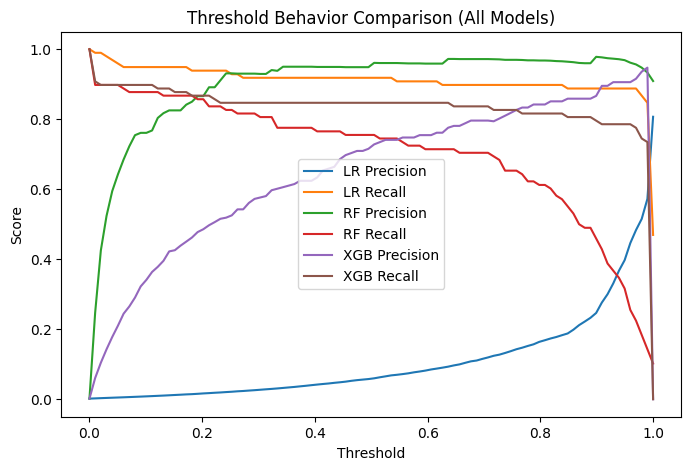

In [ ]:

thresholds = np.linspace(0, 1, 100)

prec_lr, rec_lr = [], []
prec_rf, rec_rf = [], []
prec_xgb, rec_xgb = [], []

for t in thresholds:
    # LR
    y_lr_t = (y_prob >= t).astype(int)
    prec_lr.append(precision_score(y_test, y_lr_t, zero_division=0))
    rec_lr.append(recall_score(y_test, y_lr_t))

    # RF
    y_rf_t = (y_prob_rf >= t).astype(int)
    prec_rf.append(precision_score(y_test, y_rf_t, zero_division=0))
    rec_rf.append(recall_score(y_test, y_rf_t))

    # XGB
    y_xgb_t = (y_prob_xgb >= t).astype(int)
    prec_xgb.append(precision_score(y_test, y_xgb_t, zero_division=0))
    rec_xgb.append(recall_score(y_test, y_xgb_t))

# plot
plt.figure(figsize=(8,5))

plt.plot(thresholds, prec_lr, label="LR Precision")
plt.plot(thresholds, rec_lr, label="LR Recall")

plt.plot(thresholds, prec_rf, label="RF Precision")
plt.plot(thresholds, rec_rf, label="RF Recall")

plt.plot(thresholds, prec_xgb, label="XGB Precision")
plt.plot(thresholds, rec_xgb, label="XGB Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Behavior Comparison (All Models)")
plt.legend()
plt.show()


* The threshold behavior comparison shows that Logistic Regression maintains high recall across thresholds but suffers from extremely low precision.
 * In contrast, Random Forest achieves high precision at moderate thresholds, while recall decreases as the threshold increases.
 * This highlights that Random Forest provides better control over the precision-recall trade-off.

###Conclusion:

* Logistic Regression is overly sensitive, achieving very high recall but extremely low precision, resulting in a large number of false positives.
* Random Forest is more conservative, achieving very high precision and significantly reducing false positives, but at the cost of lower recall, missing more fraud cases.
* XGBoost provides the best balance, maintaining high recall while substantially improving precision compared to Logistic Regression.
### As a result, XGBoost achieves the most effective trade-off between fraud detection and false alerts, making it the most suitable model for this problem.

#9. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=15,   # 🔥 only 15 tries instead of full grid
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [ ]:
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
tuned_metrics = get_metrics(y_test, y_pred_best, y_prob_best)

comparison_final = pd.DataFrame(
    [xgb_metrics, tuned_metrics],
    index=["XGBoost (Before Tuning)", "XGBoost (After Tuning)"]
)

comparison_final

,Precision,Recall,F1,ROC-AUC,PR-AUC
XGBoost (Before Tuning),0.715517,0.846939,0.775701,0.974735,0.850953
XGBoost (After Tuning),0.880435,0.826531,0.852632,0.972232,0.874469


Hyperparameter tuning using randomized search significantly improves model performance by increasing precision and overall F1-score, while maintaining strong recall. The improvement in PR-AUC indicates enhanced capability in handling class imbalance. The tuned model provides a better balance between fraud detection and minimizing false alerts.

#10. Cross Validation


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recall_cv = cross_val_score(best_xgb, X, y, cv=skf, scoring='recall')
pr_auc_cv = cross_val_score(best_xgb, X, y, cv=skf, scoring='average_precision')

print("Recall CV:", recall_cv.mean(), "+/-", recall_cv.std())
print("PR-AUC CV:", pr_auc_cv.mean(), "+/-", pr_auc_cv.std())

Recall CV: 0.8272108843537416 +/- 0.023320475580564843
PR-AUC CV: 0.8611764781674683 +/- 0.024467572313924116


Cross-validation results show that the tuned XGBoost model achieves a recall of approximately 0.83 and a PR-AUC of 0.86, with low variance across folds. This indicates that the model is stable and generalizes well, without significant overfitting.

#11 Final Threshold Selection

In [ ]:
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_prob_best >= t).astype(int)

    print(f"Threshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_t, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))
    print("-"*42)

Threshold: 0.2
Precision: 0.8235294117647058
Recall: 0.8571428571428571
F1: 0.84
------------------------------------------
Threshold: 0.3
Precision: 0.8383838383838383
Recall: 0.8469387755102041
F1: 0.8426395939086294
------------------------------------------
Threshold: 0.4
Precision: 0.8617021276595744
Recall: 0.826530612244898
F1: 0.84375
------------------------------------------
Threshold: 0.5
Precision: 0.8804347826086957
Recall: 0.826530612244898
F1: 0.8526315789473684
------------------------------------------
Threshold: 0.6
Precision: 0.8804347826086957
Recall: 0.826530612244898
F1: 0.8526315789473684
------------------------------------------


AUC (ROC-AUC, PR-AUC) does NOT depend on threshold

In [ ]:

thresholds = np.linspace(0, 1, 100)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)

    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

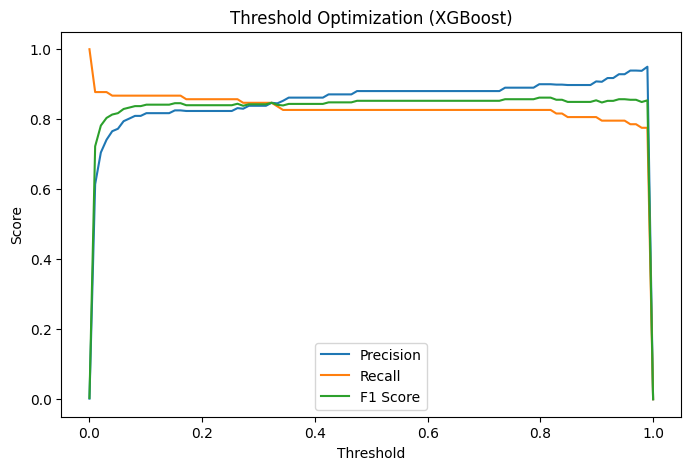

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization (XGBoost)")
plt.legend()
plt.show()

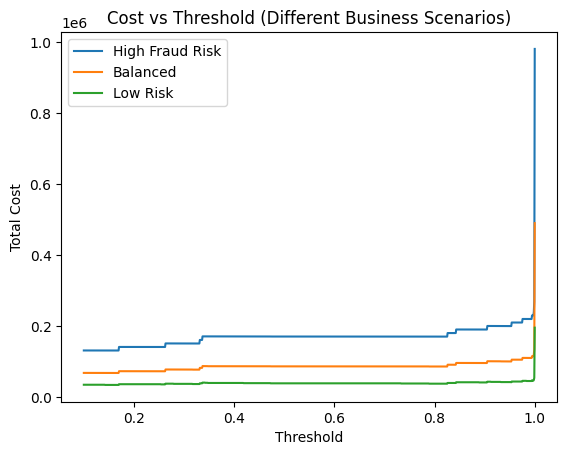

In [74]:
thresholds = np.linspace(0.1, 1, 1000)

results = []

scenarios = [
    {"FN_cost": 10000, "FP_cost": 100, "name": "High Fraud Risk"},
    {"FN_cost": 5000, "FP_cost": 200, "name": "Balanced"},
    {"FN_cost": 2000, "FP_cost": 500, "name": "Low Risk"}
]

for scenario in scenarios:
    FN_cost = scenario["FN_cost"]
    FP_cost = scenario["FP_cost"]

    costs = []

    for t in thresholds:
        y_pred_t = (y_prob_best >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        total_cost = fn * FN_cost + fp * FP_cost
        costs.append(total_cost)

    plt.plot(thresholds, costs, label=scenario["name"])

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost vs Threshold (Different Business Scenarios)")
plt.legend()
plt.show()

In [75]:
from sklearn.metrics import confusion_matrix
import pandas as pd

scenario_results = {}

for scenario in scenarios:
    FN_cost = scenario["FN_cost"]
    FP_cost = scenario["FP_cost"]
    name = scenario["name"]

    rows = []

    for t in thresholds:
        y_pred_t = (y_prob_best >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

        total_cost = fn * FN_cost + fp * FP_cost

        rows.append({
            "Threshold": t,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Total Cost": total_cost
        })

    df = pd.DataFrame(rows)
    scenario_results[name] = df

In [77]:
for name, df in scenario_results.items():
    best_idx = df["Total Cost"].idxmin()
    best_row = df.loc[best_idx]

    print(f"\nScenario: {name}")
    print("Best Threshold:", best_row["Threshold"])
    print("Total Cost:", best_row["Total Cost"])
    print("FP:", best_row["FP"], "| FN:", best_row["FN"])


Scenario: High Fraud Risk
Best Threshold: 0.14234234234234233
Total Cost: 131800.0
FP: 18.0 | FN: 13.0

Scenario: Balanced
Best Threshold: 0.14234234234234233
Total Cost: 68600.0
FP: 18.0 | FN: 13.0

Scenario: Low Risk
Best Threshold: 0.14234234234234233
Total Cost: 35000.0
FP: 18.0 | FN: 13.0


In [79]:
best_idx = np.argmax(f1_scores)

best_threshold_f1 = thresholds[best_idx]

print("Best Threshold (F1):", best_threshold_f1)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1:", f1_scores[best_idx])

Best Threshold (F1): 0.17117117117117117
Precision: 0.9
Recall: 0.826530612244898
F1: 0.8617021276595744


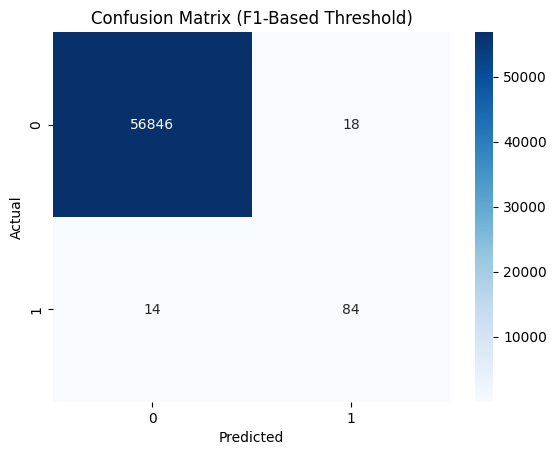

In [80]:

y_pred_f1 = (y_prob_best >= best_threshold_f1).astype(int)

cm = confusion_matrix(y_test, y_pred_f1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (F1-Based Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Two threshold selection strategies were evaluated: F1-based and cost-based. The F1-based threshold ~0.17 provided the highest balance between precision and recall. Cost-based analysis across multiple business scenarios yielded a similar threshold ~0.14, indicating that the model’s predictions are stable and robust. Since both approaches lead to nearly identical trade-offs, the F1-based threshold is selected for its simplicity and strong statistical justification.

In [81]:

importance = best_xgb.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

imp_df.head(10)

,Feature,Importance
13,V14,0.591952
3,V4,0.066373
11,V12,0.036647
6,V7,0.026889
19,V20,0.025326
28,Amount,0.019782
7,V8,0.017987
12,V13,0.017354
16,V17,0.016604
9,V10,0.015649
